In [430]:
# import numpy as np
# import pandas as pd
# import os
# import requests
# # from tensorflow.keras.models import Sequential
# # from tensorflow.keras.layers import Dense
# from urllib.parse import urlencode
# from urllib.request import Request,urlopen

In [431]:
# def get_stockData(symbol,stat):
#     # download stock file from googlefinance
#     url = 'http://finance.yahoo.com/d/quotes.csv?s=%s&f=%s'%(symbol,stat)
#     req = Request(url)
#     res = urlopen(req)
#     return str(resp.read().decode('utf-8').strip())

In [609]:
import credentials
import twitter_settings  
import imp 
imp.reload(twitter_settings)
imp.reload(credentials)
from twitter_settings import *
import mysql.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from datetime import date
import pandas_datareader.data as web
from pandas import Series, DataFrame
import matplotlib.pyplot as plt
from pandas.tseries.offsets import BDay
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import unicodedata
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)

In [692]:
def connect_db():
    mydb = mysql.connector.connect(
        host="localhost",
        user="root",
        password="*****",
        database="TwitterDB",
        auth_plugin='mysql_native_password',
        charset='utf8'  
    )
    
    return mydb

def close_db(mydb):
    mydb.close()
# if mydb.is_connected():
#     mycursor = mydb.cursor()
#     mycursor.execute("SELECT COUNT(*) FROM information_schema.tables where table_name='{0}'".
#                      format(twitter_settings.TABLE_NAME))

In [750]:
start = datetime.datetime(2017, 1, 1)
end = date.today()

stock_df = web.DataReader("NFLX", 'yahoo', start, end)
stock_df.tail()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2019-11-21,312.6900,304.2600,306.0000,311.6900,7488400,311.6900
2019-11-22,311.4000,304.4100,309.1000,310.4800,5970100,310.4800
2019-11-25,315.7300,305.2500,308.8300,315.5500,7873900,315.5500
2019-11-26,316.5000,311.6900,315.0000,312.4900,5321000,312.4900
2019-11-27,316.3600,313.3700,313.9300,314.6789,907323,314.6789


In [694]:
stock_df.shape

(731, 6)

In [751]:
#close_px = df['Adj Close']
stock_df['mvg_avg'] = stock_df['Adj Close'].rolling(window=100).mean()
stock_df[['Adj Close','mvg_avg']]

,Adj Close,mvg_avg
Date,,
2017-01-03,127.4900,nan
2017-01-04,129.4100,nan
2017-01-05,131.8100,nan
2017-01-06,131.0700,nan
2017-01-09,130.9500,nan
2017-01-10,129.8900,nan
2017-01-11,130.5000,nan
2017-01-12,129.1800,nan
2017-01-13,133.7000,nan


## Plot moving average of stock price

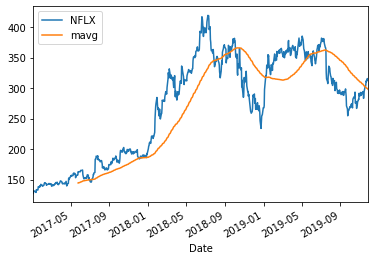

In [752]:

stock_df['Adj Close'].plot(label='NFLX')
stock_df['mvg_avg'].plot(label='mavg')
plt.legend()

In [753]:
stock_df['pcnt_change'] = stock_df['Adj Close'].pct_change()

In [754]:
stock_df

,High,Low,Open,Close,Volume,Adj Close,mvg_avg,pcnt_change
Date,,,,,,,,
2017-01-03,128.1900,124.3100,124.9600,127.4900,9437900,127.4900,nan,nan
2017-01-04,130.1700,126.5500,127.4900,129.4100,7843600,129.4100,nan,0.0151
2017-01-05,132.7500,128.9000,129.2200,131.8100,10185500,131.8100,nan,0.0185
2017-01-06,133.8800,129.8100,132.0800,131.0700,10657900,131.0700,nan,-0.0056
2017-01-09,131.9900,129.8900,131.4800,130.9500,5771800,130.9500,nan,-0.0009
2017-01-10,132.2200,129.2900,131.2700,129.8900,5985800,129.8900,nan,-0.0081
2017-01-11,131.5000,129.2500,130.9100,130.5000,5615100,130.5000,nan,0.0047
2017-01-12,130.8500,128.5000,130.6300,129.1800,5388900,129.1800,nan,-0.0101
2017-01-13,133.9300,130.5800,131.1500,133.7000,10515000,133.7000,nan,0.0350


## Plot Percentage change from previous day in stock price

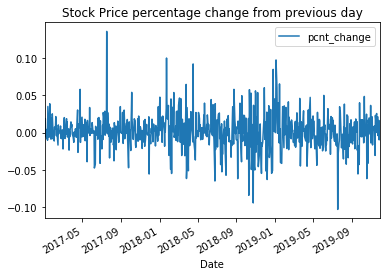

In [755]:
#stock_df['Adj Close'].plot(label='NFLX')
stock_df['pcnt_change'].plot(label='pcnt_change')
plt.title('Stock Price percentage change from previous day')
plt.legend();

## Plot Percentage change in stock Price staring from 2019-11-15

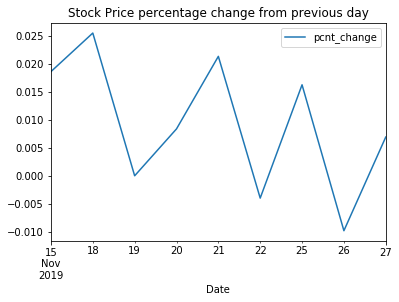

In [756]:
#stock_df['Adj Close'].plot(label='NFLX')
stock_df.loc['2019-11-15':,'pcnt_change'].plot(label='pcnt_change')
plt.title('Stock Price percentage change from previous day')
plt.legend();

## Netflix query

In [765]:
## Open db connection
mydb = connect_db()
netflix_query = "SELECT id_str, created_at, track, text, polarity, compound_score ,negative_score ,positive_score ,neutral_score, hashtags, user_location FROM {} where track like 'Netflix' order by created_at desc" \
                     .format(twitter_settings.HISTORY_TABLE_NAME)
netflix_tweets_df = pd.read_sql(netflix_query,con=mydb)
netflix_tweets_df["created_at"]=netflix_tweets_df.created_at.astype(np.datetime64)
close_db(mydb)
netflix_tweets_df#.head()

,id_str,created_at,track,text,polarity,compound_score,negative_score,positive_score,neutral_score,hashtags,user_location
0,1199710425379684352,2019-11-27 10:23:49,Netflix,THE IRISHMAN is now finally streaming on Netfl...,0,0.0000,0.0000,0.0000,1.0000,[],"Missoula, MT"
1,1199710035577839622,2019-11-27 10:22:16,Netflix,hello i need the third season or anne with a e...,0,0.0000,0.0000,0.0000,1.0000,[],None
2,1199709953545703430,2019-11-27 10:21:57,Netflix,Because the people who can save it really do h...,1,0.1868,0.0830,0.1080,0.8090,[],None
3,1199709579984150529,2019-11-27 10:20:28,Netflix,THE IRISHMAN is on Netflix today You should ab...,1,0.4588,0.0000,0.1200,0.8800,[],Earth
4,1199709435116965889,2019-11-27 10:19:53,Netflix,im still not over this can someone give me a m...,0,0.0000,0.0000,0.0000,1.0000,[],cha . cosmic atte
5,1199709109647396864,2019-11-27 10:18:35,Netflix,Rainy days are perfect for sad music and binge...,1,0.0772,0.2430,0.2040,0.5520,[],None
6,1199708568217432064,2019-11-27 10:16:26,Netflix,THE IRISHMAN is now finally streaming on Netfl...,0,0.0000,0.0000,0.0000,1.0000,[],"Gamehendge, NY"
7,1199708314566823938,2019-11-27 10:15:26,Netflix,Omg i feel the same I sadly still waste hours ...,-1,-0.4215,0.1670,0.0000,0.8330,[],Italy
8,1199708274871848961,2019-11-27 10:15:16,Netflix,The bread and circuses or in the modern sense ...,0,0.0000,0.0000,0.0000,1.0000,[],"Tigard, OR"
9,1199708158328889344,2019-11-27 10:14:49,Netflix,whispers pitch it to Netflix or SyFy,0,0.0000,0.0000,0.0000,1.0000,[],"New York, NY"


In [766]:
netflix_tweets_df["created_at"]=netflix_tweets_df["created_at"].dt.date
netflix_tweets_df["created_at"]=netflix_tweets_df["created_at"].astype(np.datetime64)
netflix_tweets_df.groupby(['created_at','polarity']).mean()

compound_score  negative_score  positive_score  \
created_at polarity                                                   
2019-11-15 -1               -0.4307          0.2269          0.0439   
            0                0.0000          0.0000          0.0000   
            1                0.4198          0.0124          0.2031   
2019-11-18 -1               -0.4669          0.2089          0.0224   
            0                0.0000          0.0140          0.0140   
            1                0.5754          0.0138          0.2596   
2019-11-19 -1               -0.4109          0.1430          0.0000   
            0                0.0000          0.0000          0.0000   
            1                0.4964          0.0000          0.2353   
2019-11-20 -1               -0.4118          0.1988          0.0292   
            0                0.0000          0.0000          0.0000   
            1                0.6983          0.0000          0.2990   
2019-11-21 -1               -0.4183          0.1853          0.0158   
            0                0.0000          0.0000          0.0000   
            1                0.4545          0.0171          0.2095   
2019-11-22 -1               -0.6020          0.2097          0.0483   
            0               -0.0016          0.0043          0.0000   
            1                0.5728          0.0080          0.2634   
2019-11-24  0                0.0000          0.0000          0.0000   
2019-11-25 -1               -0.5243          0.2093          0.0000   
            0                0.0000          0.0000          0.0000   
            1                0.3773          0.0488          0.1522   
2019-11-26 -1               -0.3821          0.1852          0.0579   
            0                0.0000          0.0000          0.0000   
            1                0.4641          0.0322          0.2344   
2019-11-27 -1               -0.4819          0.2020          0.0370   
            0                0.0000          0.0000          0.0000   
            1                0.4090          0.0467          0.2017   

                     neutral_score  
created_at polarity                 
2019-11-15 -1               0.7294  
            0               1.0000  
            1               0.7844  
2019-11-18 -1               0.7687  
            0               0.9720  
            1               0.7265  
2019-11-19 -1               0.8570  
            0               1.0000  
            1               0.7647  
2019-11-20 -1               0.7720  
            0               1.0000  
            1               0.7010  
2019-11-21 -1               0.7987  
            0               1.0000  
            1               0.7735  
2019-11-22 -1               0.7420  
            0               0.9958  
            1               0.7286  
2019-11-24  0               1.0000  
2019-11-25 -1               0.7907  
            0               1.0000  
            1               0.7992  
2019-11-26 -1               0.7569  
            0               1.0000  
            1               0.7333  
2019-11-27 -1               0.7611  
            0               1.0000  
            1               0.7516

## Mean ploarity over time

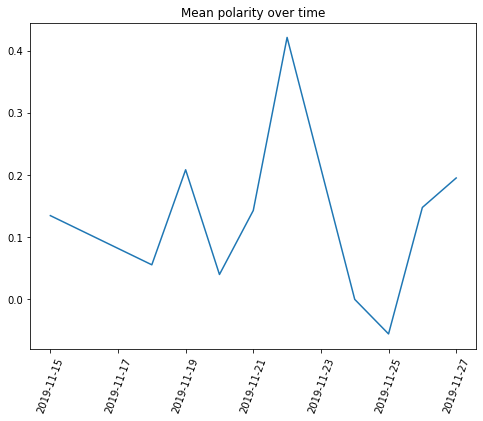

In [767]:
mean_pol = list(dict(netflix_tweets_df.groupby('created_at')['polarity'].mean()).items())
mean_pol.sort(key=lambda x: x[0])

plt.figure(figsize=(8,6))
plt.plot([i[0] for i in mean_pol], [i[1] for i in mean_pol])
plt.xticks(rotation=70)
plt.title('Mean polarity over time');

In [768]:
from operator import methodcaller
#s.map(lambda x: x.strftime('%d-%m-%Y')
stocks_date_creation_list = list(stock_df.index.map(lambda x: x.strftime('%Y-%m-%d')))
stocks_date_creation_list

['2017-01-03',
 '2017-01-04',
 '2017-01-05',
 '2017-01-06',
 '2017-01-09',
 '2017-01-10',
 '2017-01-11',
 '2017-01-12',
 '2017-01-13',
 '2017-01-17',
 '2017-01-18',
 '2017-01-19',
 '2017-01-20',
 '2017-01-23',
 '2017-01-24',
 '2017-01-25',
 '2017-01-26',
 '2017-01-27',
 '2017-01-30',
 '2017-01-31',
 '2017-02-01',
 '2017-02-02',
 '2017-02-03',
 '2017-02-06',
 '2017-02-07',
 '2017-02-08',
 '2017-02-09',
 '2017-02-10',
 '2017-02-13',
 '2017-02-14',
 '2017-02-15',
 '2017-02-16',
 '2017-02-17',
 '2017-02-21',
 '2017-02-22',
 '2017-02-23',
 '2017-02-24',
 '2017-02-27',
 '2017-02-28',
 '2017-03-01',
 '2017-03-02',
 '2017-03-03',
 '2017-03-06',
 '2017-03-07',
 '2017-03-08',
 '2017-03-09',
 '2017-03-10',
 '2017-03-13',
 '2017-03-14',
 '2017-03-15',
 '2017-03-16',
 '2017-03-17',
 '2017-03-20',
 '2017-03-21',
 '2017-03-22',
 '2017-03-23',
 '2017-03-24',
 '2017-03-27',
 '2017-03-28',
 '2017-03-29',
 '2017-03-30',
 '2017-03-31',
 '2017-04-03',
 '2017-04-04',
 '2017-04-05',
 '2017-04-06',
 '2017-04-

## FInd the maximum daily polarity and average compound score

In [769]:
def pcnt_check(text):
    try:
        return stock_df.loc[text,'pcnt_change']
    except:
        return 0.0

created_at_list_master=list(set(netflix_tweets_df["created_at"]))

created_at_list=[]
for list_val in created_at_list_master:
    created_at_list.append(str(list_val).split('Timestamp(')[0].split(' ')[0])
created_at_list=sorted(created_at_list)
netflix_avgdaily_df = pd.DataFrame(columns=['created_at','polarity_count','polarity','avg_compound_score'])
for index,date_val in enumerate(created_at_list):
    if date_val in stocks_date_creation_list:
        value_count_series=netflix_tweets_df[netflix_tweets_df["created_at"]==date_val]['polarity'].value_counts()
        polarity_count=value_count_series.max()
        polarity=value_count_series.idxmax()
        coumpound_score=netflix_tweets_df[(netflix_tweets_df["created_at"]==date_val) & 
                      (netflix_tweets_df["polarity"]==polarity)]['compound_score'].mean()
        netflix_avgdaily_df.loc[index,'created_at']=date_val
        netflix_avgdaily_df.loc[index,'polarity_count']=polarity_count
        netflix_avgdaily_df.loc[index,'polarity']=polarity
        netflix_avgdaily_df.loc[index,'avg_compound_score']=coumpound_score

        #netflix_avgdaily_df['pcnt_change']= netflix_avgdaily_df['created_at'].apply(pcnt_check)
        netflix_avgdaily_df['pcnt_change']= netflix_avgdaily_df['created_at'].apply(lambda x: stock_df.loc[x,'pcnt_change'])

netflix_avgdaily_df

#netflix_tweets_df[netflix_tweets_df["created_at"]=='2019-11-21']['polarity'].value_counts()

,created_at,polarity_count,polarity,avg_compound_score,pcnt_change
0,2019-11-15,21.0000,1.0000,0.4198,0.0187
1,2019-11-18,23.0000,0.0000,0.0000,0.0256
2,2019-11-19,15.0000,0.0000,0.0000,0.0001
3,2019-11-20,14.0000,0.0000,0.0000,0.0085
4,2019-11-21,18.0000,0.0000,0.0000,0.0214
5,2019-11-22,19.0000,1.0000,0.5728,-0.0039
7,2019-11-25,7.0000,0.0000,0.0000,0.0163
8,2019-11-26,41.0000,0.0000,0.0000,-0.0097
9,2019-11-27,19.0000,0.0000,0.0000,0.0070


In [746]:
# netflix_avgdaily_df.drop(index=netflix_avgdaily_df.loc[
#     netflix_avgdaily_df['created_at']=='2019-11-25'].index[0],inplace=True)
# netflix_avgdaily_df=netflix_avgdaily_df.reset_index(drop=True)
# netflix_avgdaily_df

In [770]:
netflix_avgdaily_df['created_at'] = netflix_avgdaily_df['created_at'].astype(np.datetime64)
netflix_avgdaily_df['polarity_count'] = netflix_avgdaily_df['polarity_count'].astype(np.int)
netflix_avgdaily_df['polarity'] = netflix_avgdaily_df['polarity'].astype(np.int)
netflix_avgdaily_df['avg_compound_score'] = netflix_avgdaily_df['avg_compound_score'].astype(np.float)
netflix_avgdaily_df['pcnt_change'] = netflix_avgdaily_df['pcnt_change'].astype(np.float)
netflix_avgdaily_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9 entries, 0 to 9
Data columns (total 5 columns):
created_at            9 non-null datetime64[ns]
polarity_count        9 non-null int64
polarity              9 non-null int64
avg_compound_score    9 non-null float64
pcnt_change           9 non-null float64
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 752.0 bytes


## Find Correlation between Sentiment Compound Score and Percentage change in stock price from previous day

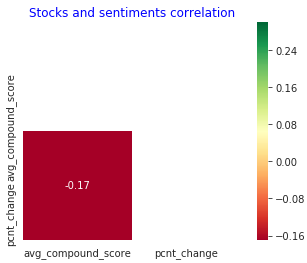

In [771]:
mask = np.zeros_like(netflix_avgdaily_df[['avg_compound_score','pcnt_change']].corr())
mask[np.triu_indices_from(mask)] = True
with sns.axes_style("white"):
      sns.heatmap(netflix_avgdaily_df[['avg_compound_score','pcnt_change']].corr(),mask=mask,vmax=.3, square=True, annot=True,
                 cmap='RdYlGn',fmt='.2f');
plt.title("Stocks and sentiments correlation",color='blue');

## Stats
- Nul Hypothesis
- p-value
- r2 score

In [772]:
y=netflix_avgdaily_df[['pcnt_change']]
X=netflix_avgdaily_df[['avg_compound_score']]
combined_lm = sm.OLS(y, X).fit()

In [773]:
combined_lm.summary()

/Users/vidhu/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1450: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=9
  "anyway, n=%i" % int(n))


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            pcnt_change   R-squared (uncentered):                   0.032
Model:                            OLS   Adj. R-squared (uncentered):             -0.089
Method:                 Least Squares   F-statistic:                             0.2643
Date:                Wed, 27 Nov 2019   Prob (F-statistic):                       0.621
Time:                        23:27:07   Log-Likelihood:                          25.328
No. Observations:                   9   AIC:                                     -48.66
Df Residuals:                       8   BIC:                                     -48.46
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
avg_compound_score     0.0111      0.022      0.514      0.621      -0.039       0.061
==============================================================================
Omnibus:                        0.757   Durbin-Watson:                   1.946
Prob(Omnibus):                  0.685   Jarque-Bera (JB):                0.594
Skew:                          -0.249   Prob(JB):                        0.743
Kurtosis:                       1.844   Cond. No.                         1.00
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Obnservations from above model
- 3.2% of the variation in pcnt_change of stock price is explained by compound_score feature
- Null Hypothesis - there is no relationship between pcnt_change in stock price and compound_score of the tweets
- Since the p-value is 0.621 so there is not enough evidence to reject the Null Hypothesis

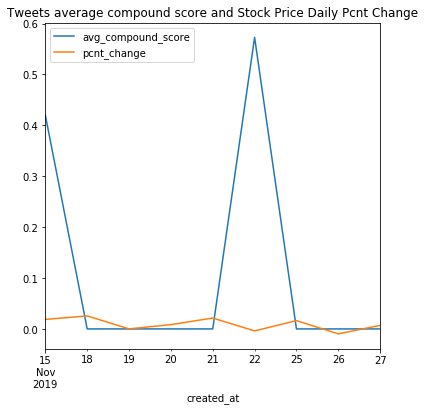

In [774]:
plt.figure(figsize=(6,6))
avgdaily_plot_df = netflix_avgdaily_df.copy()
avgdaily_plot_df.set_index('created_at',inplace=True)
avgdaily_plot_df['avg_compound_score'].plot(label='avg_compound_score')
avgdaily_plot_df['pcnt_change'].plot(label='pcnt_change');
plt.title('Tweets average compound score and Stock Price Daily Pcnt Change')
plt.legend();

# Extra

In [472]:
netflix_tweets_df[netflix_tweets_df["created_at"]=='2019-11-21'].sort_values(by=['polarity','compound_score'])

,id_str,created_at,track,text,polarity,compound_score,negative_score,positive_score,neutral_score,hashtags,user_location
71,1197665778184720385,2019-11-21,Netflix,This should scare the hell out of the Netflix ...,-1,-0.8316,0.3280,0.0000,0.6720,"['BabyYoda', 'Yoda', 'TheMandalorian']",None
38,1197665994937917440,2019-11-21,Netflix,It makes me sad that my only way of watching t...,-1,-0.4767,0.1140,0.0000,0.8860,[],None
65,1197665828231102464,2019-11-21,Netflix,e portanto cabe ao felipe neto fazer a netflix...,-1,-0.3612,0.2170,0.0000,0.7830,[],power to the local dreamer
40,1197665990676566016,2019-11-21,Netflix,From hot to toxic yoga a new Netflix film docu...,-1,-0.3182,0.0990,0.0000,0.9010,[],Ottawa & Toronto
48,1197665924280733697,2019-11-21,Netflix,my notes app be like Grocery list Future baby ...,-1,-0.2960,0.1410,0.0950,0.7630,[],None
59,1197665868492095488,2019-11-21,Netflix,oh man Marie Kondo should ve stopped at Netflix,-1,-0.2263,0.2130,0.0000,0.7870,[],NorCal
39,1197665991695753217,2019-11-21,Netflix,So DragRaceUK finished think I m gonna binge w...,0,0.0000,0.0000,0.0000,1.0000,['DragRaceUK'],United Kingdom
41,1197665980027158528,2019-11-21,Netflix,le film est A1 btw sur netflix,0,0.0000,0.0000,0.0000,1.0000,[],Montral
42,1197665979628695553,2019-11-21,Netflix,Netflix is doing Gods work,0,0.0000,0.0000,0.0000,1.0000,[],None
45,1197665954898927616,2019-11-21,Netflix,When he invites you to Netflix amp chill but d...,0,0.0000,0.0000,0.0000,1.0000,[],"Los Angeles, CA"


## Lets Create a dataframe and combine the tweets date wise - will check overall compound score of all tweets in a day

In [445]:
#combined_tweet_copy_df = combined_tweet_df.copy()
combined_tweet_df=pd.DataFrame(columns=['created_at','text'])

indx=0
get_tweet=""
for i in range(0,len(netflix_tweets_df)-1):
    get_date=netflix_tweets_df['created_at'].iloc[i]
    next_date=netflix_tweets_df['created_at'].iloc[i+1]
    if(str(get_date)==str(next_date)):
        get_tweet=get_tweet+netflix_tweets_df['text'].iloc[i]+" "
    if(str(get_date)!=str(next_date)):
        combined_tweet_df.set_value(indx,'created_at',get_date)
        combined_tweet_df.set_value(indx,'text',get_tweet)
        indx=indx+1
        get_tweet=" "

combined_tweet_df['created_at']=combined_tweet_df['created_at'].astype(np.datetime64)

isBusinessDay = BDay().onOffset
match_series = pd.to_datetime(combined_tweet_df['created_at']).map(isBusinessDay)
        

        
combined_tweet_df=combined_tweet_df[match_series]
combined_tweet_df


/Users/vidhu/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:12: FutureWarning: set_value is deprecated and will be removed in a future release. Please use .at[] or .iat[] accessors instead
  if sys.path[0] == '':
/Users/vidhu/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:13: FutureWarning: set_value is deprecated and will be removed in a future release. Please use .at[] or .iat[] accessors instead
  del sys.path[0]


,created_at,text
0,2019-11-22,SORTEO RANDOM SEMI FULL ACCES UNMIGRATED FULL ...
1,2019-11-21,It makes me sad that my only way of watching ...
2,2019-11-20,netflix and chi sleep tfw you realize THE IRI...
3,2019-11-19,Anime Netflix Adaptation Your 8 99 Netflix su...
4,2019-11-18,Nobody paksa you subscribe to Netflix Nobody ...


In [446]:
#combined_tweet_df['pcnt_change']=stock_df[]
combined_tweet_df['pcnt_change']= combined_tweet_df['created_at'].apply(lambda x: stock_df.loc[x,'pcnt_change'])
combined_tweet_df

,created_at,text,pcnt_change
0,2019-11-22,SORTEO RANDOM SEMI FULL ACCES UNMIGRATED FULL ...,-0.0039
1,2019-11-21,It makes me sad that my only way of watching ...,0.0214
2,2019-11-20,netflix and chi sleep tfw you realize THE IRI...,0.0085
3,2019-11-19,Anime Netflix Adaptation Your 8 99 Netflix su...,0.0001
4,2019-11-18,Nobody paksa you subscribe to Netflix Nobody ...,0.0256


In [447]:
analyser = SentimentIntensityAnalyzer()

for row_index, row in combined_tweet_df.T.iteritems():
    try:
        tweet = unicodedata.normalize('NFKD', combined_tweet_df.loc[row_index, 'text'])
        score = analyser.polarity_scores(tweet)
        combined_tweet_df.set_value(row_index, 'compound_score', score['compound'])
        combined_tweet_df.set_value(row_index, 'negative_score', score['neg'])
        combined_tweet_df.set_value(row_index, 'neutral_score', score['neu'])
        combined_tweet_df.set_value(row_index, 'positive_score', score['pos'])
        if score['compound']>=0.05: #positive
            polarity = 1
        elif (score['compound']>-0.05) & (score['compound']<0.05): #neutral
            polarity = 0
        elif score['compound']<=-0.05: #negative
            polarity = -1
        combined_tweet_df.set_value(row_index, 'polarity', polarity)
    except TypeError:
        print (combined_tweet_df.loc[row_index, 'text'])
        print (row_index)

combined_tweet_df

/Users/vidhu/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:7: FutureWarning: set_value is deprecated and will be removed in a future release. Please use .at[] or .iat[] accessors instead
  import sys
/Users/vidhu/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:8: FutureWarning: set_value is deprecated and will be removed in a future release. Please use .at[] or .iat[] accessors instead
  
/Users/vidhu/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:9: FutureWarning: set_value is deprecated and will be removed in a future release. Please use .at[] or .iat[] accessors instead
  if __name__ == '__main__':
/Users/vidhu/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:10: FutureWarning: set_value is deprecated and will be removed in a future release. Please use .at[] or .iat[] accessors instead
  # Remove the CWD from sys.path while we load stuff.
/Users/vidhu/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:17: FutureWarning: set_

,created_at,text,pcnt_change,compound_score,negative_score,neutral_score,positive_score,polarity
0,2019-11-22,SORTEO RANDOM SEMI FULL ACCES UNMIGRATED FULL ...,-0.0039,0.9980,0.0710,0.7250,0.2050,1.0000
1,2019-11-21,It makes me sad that my only way of watching ...,0.0214,0.9721,0.0640,0.8300,0.1060,1.0000
2,2019-11-20,netflix and chi sleep tfw you realize THE IRI...,0.0085,0.9396,0.0550,0.8340,0.1100,1.0000
3,2019-11-19,Anime Netflix Adaptation Your 8 99 Netflix su...,0.0001,0.8937,0.0270,0.9090,0.0650,1.0000
4,2019-11-18,Nobody paksa you subscribe to Netflix Nobody ...,0.0256,0.9922,0.1010,0.7510,0.1480,1.0000


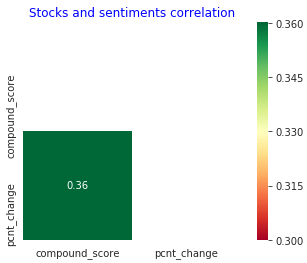

In [448]:
mask = np.zeros_like(combined_tweet_df[['compound_score','pcnt_change']].corr())
mask[np.triu_indices_from(mask)] = True
with sns.axes_style("white"):
      sns.heatmap(combined_tweet_df[['compound_score','pcnt_change']].corr(),mask=mask,vmax=.3, square=True, annot=True,
                 cmap='RdYlGn',fmt='.2f');
plt.title("Stocks and sentiments correlation",color='blue');

In [449]:
y=combined_tweet_df[['pcnt_change']]
X=combined_tweet_df[['compound_score']]
combined_lm = sm.OLS(y, X).fit()

In [450]:
combined_lm.summary()

/Users/vidhu/anaconda3/lib/python3.7/site-packages/statsmodels/stats/stattools.py:71: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  "samples were given." % int(n), ValueWarning)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            pcnt_change   R-squared (uncentered):                   0.459
Model:                            OLS   Adj. R-squared (uncentered):              0.324
Method:                 Least Squares   F-statistic:                              3.393
Date:                Sun, 24 Nov 2019   Prob (F-statistic):                       0.139
Time:                        21:39:17   Log-Likelihood:                          15.283
No. Observations:                   5   AIC:                                     -28.57
Df Residuals:                       4   BIC:                                     -28.96
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
compound_score     0.0109      0.006      1.842      0.139      -0.006       0.027
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   2.265
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.541
Skew:                           0.081   Prob(JB):                        0.763
Kurtosis:                       1.396   Cond. No.                         1.00
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Obnservations from above model
- 47% of the variation in pcnt_change of stock price is explained by compound_score feature
- Since the p-value is 0.135 so there is not enough evidence to reject the Null Hypothese that there is no relationship between pcnt_change in stock price and compound_score of the tweets

In [451]:
combined_lm.pvalues

compound_score   0.1393
dtype: float64

In [452]:
combined_lm.f_pvalue

0.13927763199698134

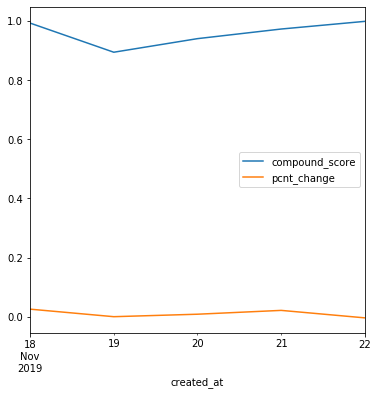

In [453]:
plt.figure(figsize=(6,6))
combined_tweet_plot_df = combined_tweet_df.copy()
combined_tweet_plot_df.set_index('created_at',inplace=True)
combined_tweet_plot_df['compound_score'].plot(label='compound_score')
combined_tweet_plot_df['pcnt_change'].plot(label='pcnt_change');
plt.legend();